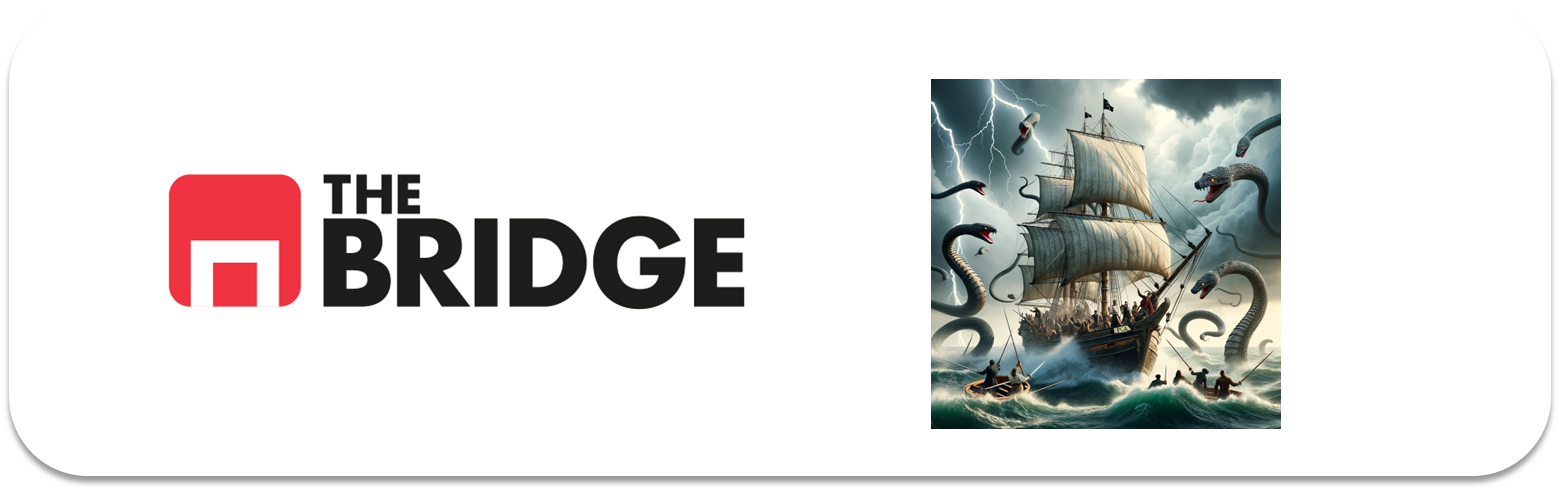

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Tratamiento de datos
import numpy as np
import pandas as pd

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

%matplotlib inline
plt.style.use("ggplot")

# Dataset y modelado
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import balanced_accuracy_score

import warnings
warnings.filterwarnings("ignore")

# Semilla fija para que toda la practica sea reproducible
RANDOM_STATE = 42

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




In [2]:
# Descargamos el dataset de caras de Olivetti con la funcion de sklearn
faces = fetch_olivetti_faces()

X = faces.data        # 400 imagenes aplanadas a 4096 pixeles (64x64)
y = faces.target      # identidad de la persona: 40 clases (0-39), 10 fotos cada una

print("Forma de X (instancias, pixeles):", X.shape)
print("Forma de y:", y.shape)
print("Numero de clases:", np.unique(y).size, "| imagenes por clase:", np.bincount(y)[0])
print("Rango de los pixeles:", X.min(), "-", X.max())

Forma de X (instancias, pixeles): (400, 4096)
Forma de y: (400,)
Numero de clases: 40 | imagenes por clase: 10
Rango de los pixeles: 0.0 - 1.0


In [3]:
# 1. Construimos un DataFrame: una fila por imagen, una columna por pixel + el target
col_names = [f"px_{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=col_names)
df["target"] = y
df.head()

,px_0,px_1,px_2,px_3,px_4,px_5,px_6,px_7,px_8,px_9,...,px_4087,px_4088,px_4089,px_4090,px_4091,px_4092,px_4093,px_4094,px_4095,target
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025,0
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893,0
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893,0
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669,0
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554,0


In [4]:
# 2. Split train/test ESTRATIFICADO por el target.
# Tenemos 400 imagenes y 40 clases. Con test_size=0.2 -> 80 imagenes en test
# (2 por clase), que cumple el minimo de 80 pedido. Guardamos este split y lo
# reutilizamos en TODA la practica.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Clases en test:", np.unique(y_test).size, "| imagenes por clase en test:", np.bincount(y_test)[0])

Train: (320, 4096) | Test: (80, 4096)
Clases en test: 40 | imagenes por clase en test: 2


**3. Quick miniEDA**

El dataset de Olivetti es muy "limpio" para un EDA clasico:

- No hay valores nulos: son imagenes, todos los pixeles tienen valor.
- Todas las features estan en la **misma escala** [0, 1] (sklearn ya las normaliza), asi que **no necesitamos `StandardScaler`**. Ademas, estandarizar pixel a pixel daria mucho peso a esquinas casi siempre negras (poca varianza, mucho ruido) y complicaria la reconstruccion de las caras en las partes 2 y 3.
- El target esta **perfectamente balanceado** (10 imagenes por persona), por lo que `balanced_accuracy` se comporta practicamente igual que la accuracy. Lo comprobamos abajo.

Por eso el EDA se reduce a confirmar el balanceo del target y echar un vistazo a unas cuantas caras.

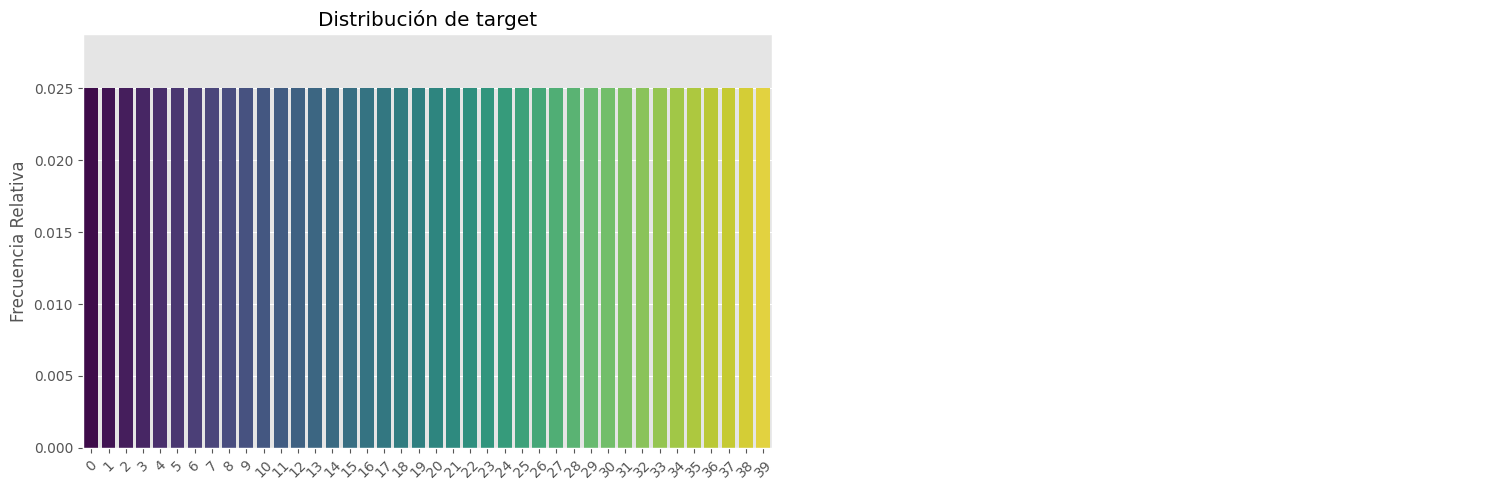

In [5]:
# Distribucion del target (usamos bootcampviztools). Esperamos 40 clases iguales.
bt.pinta_distribucion_categoricas(df, ["target"], relativa=True)

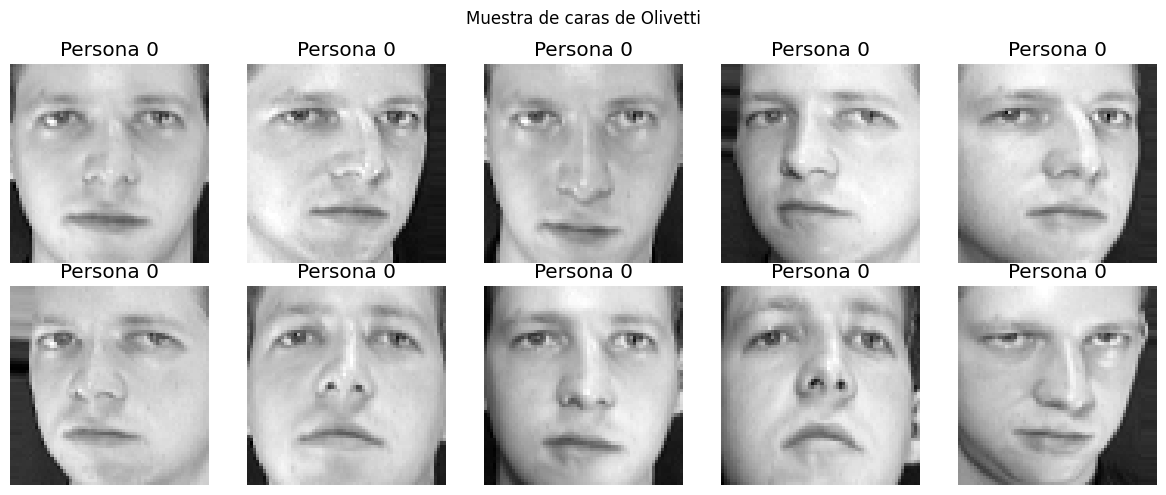

In [6]:
# Echamos un vistazo a 10 caras del dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, label in zip(axes.ravel(), faces.images[:10], y[:10]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Persona {label}")
    ax.axis("off")
plt.suptitle("Muestra de caras de Olivetti")
plt.tight_layout()
plt.show()

In [7]:
# 4. Modelo BASELINE usando TODOS los pixeles (sin comprimir).
# Elegimos Regresion Logistica: es simple, rapida y da muy buen resultado en
# este dataset (mejor que KNN y que un SVC por defecto, lo comprobamos aparte).
modelo_base = LogisticRegression(max_iter=2000)

# Recall media = balanced_accuracy en validacion cruzada de 5 folds sobre TRAIN
base_cv = cross_val_score(
    modelo_base, X_train, y_train, cv=5, scoring="balanced_accuracy"
).mean()

# Y la misma metrica sobre el conjunto de TEST
modelo_base.fit(X_train, y_train)
base_test = balanced_accuracy_score(y_test, modelo_base.predict(X_test))

print(f"BASELINE -> CV (5 folds): {base_cv:.4f} | Test: {base_test:.4f}")

BASELINE -> CV (5 folds): 0.9550 | Test: 0.9750


Guardamos `base_cv` y `base_test` como referencia (baseline) para comparar en las siguientes partes. Con todas las features el modelo es muy bueno, asi que tenemos un punto de partida exigente.

### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

**Nota sobre la "compresion":** cada imagen pasa de 4096 pixeles a `k` componentes principales, asi que el factor de compresion (tamano final respecto al original) es:

$$\text{compresion} = \frac{k}{4096}$$

Una compresion del 1% significa quedarnos con ~41 componentes. *Mayor compresion* = *menos componentes* = *menos tamano*.

In [8]:
# 1. PCA sobre los datos de Train SIN pasar argumentos (todas las componentes)
n_pixeles = X_train.shape[1]   # 4096
pca_full = PCA()
pca_full.fit(X_train)

# Proyectamos train y test con ESE mismo PCA (el test NO se reentrena)
X_train_pca = pca_full.transform(X_train)
X_test_pca  = pca_full.transform(X_test)
print("X_train_pca:", X_train_pca.shape)

X_train_pca: (320, 320)


In [9]:
# 2. Rango de numero de componentes con compresion entre 0.2% y 2.5%.
# 0.2% -> ~8 componentes ; 2.5% -> ~102 componentes
print("0.2% ->", round(0.002 * n_pixeles), "comp | 2.5% ->", round(0.025 * n_pixeles), "comp")
componentes_p2 = [8, 25, 50, 75, 102]
print("Valores a probar:", componentes_p2)

0.2% -> 8 comp | 2.5% -> 102 comp
Valores a probar: [8, 25, 50, 75, 102]


In [10]:
# 3 y 4. Para cada k: balanced_accuracy en CV (5 folds) y en test, y montamos la tabla.
# Como las componentes del PCA estan ordenadas, quedarnos con las primeras k columnas
# de X_train_pca equivale a un PCA(n_components=k).
filas = []
for k in componentes_p2:
    clf = LogisticRegression(max_iter=2000)
    cv_k = cross_val_score(
        clf, X_train_pca[:, :k], y_train, cv=5, scoring="balanced_accuracy"
    ).mean()
    clf.fit(X_train_pca[:, :k], y_train)
    test_k = balanced_accuracy_score(y_test, clf.predict(X_test_pca[:, :k]))
    filas.append({
        "n_componentes": k,
        "compresion_%": round(k / n_pixeles * 100, 3),
        "CV_balanced_acc": round(cv_k, 4),
        "test_balanced_acc": round(test_k, 4),
        "dif_CV_vs_base": round(cv_k - base_cv, 4),
        "dif_test_vs_base": round(test_k - base_test, 4),
    })

resultados_p2 = pd.DataFrame(filas)
resultados_p2

,n_componentes,compresion_%,CV_balanced_acc,test_balanced_acc,dif_CV_vs_base,dif_test_vs_base
0,8,0.195,0.7725,0.8000,-0.1825,-0.1750
1,25,0.610,0.9575,0.9375,0.0025,-0.0375
2,50,1.221,0.9625,0.9625,0.0075,-0.0125
3,75,1.831,0.9600,0.9750,0.0050,0.0000
4,102,2.490,0.9600,0.9625,0.0050,-0.0125


In [11]:
# 5. Elegimos la MAYOR compresion (menos componentes) con perdida < 3 pp en CV y en test.
# Si no hubiera ninguno, relajamos el criterio a 5 pp.
margen = 0.03
candidatos = resultados_p2[(resultados_p2["dif_CV_vs_base"] > -margen) &
                           (resultados_p2["dif_test_vs_base"] > -margen)]
if candidatos.empty:
    margen = 0.05
    candidatos = resultados_p2[(resultados_p2["dif_CV_vs_base"] > -margen) &
                               (resultados_p2["dif_test_vs_base"] > -margen)]
    print("No hay opcion con <3pp; aplicamos el criterio de <5pp")

elegido_p2 = int(candidatos.sort_values("n_componentes").iloc[0]["n_componentes"])
print(f"Componentes elegidos (Parte 2): {elegido_p2}")
print(f"-> compresion {elegido_p2 / n_pixeles * 100:.2f}% y perdida < {margen*100:.0f} pp en CV y test")

Componentes elegidos (Parte 2): 50
-> compresion 1.22% y perdida < 3 pp en CV y test


### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

In [12]:
# 1. Rango con compresion AUN MAYOR: entre 0.1% (1 por mil) y 1% (1 por ciento).
# 0.1% -> ~4 componentes ; 1% -> ~41 componentes
print("0.1% ->", round(0.001 * n_pixeles), "comp | 1% ->", round(0.01 * n_pixeles), "comp")
componentes_p3 = [4, 10, 20, 30, 41]
print("Valores a probar:", componentes_p3)

0.1% -> 4 comp | 1% -> 41 comp
Valores a probar: [4, 10, 20, 30, 41]


In [13]:
# 2. Para cada k: PCA sobre X_train, descomprimimos con inverse_transform y
#    entrenamos el modelo sobre los datos DESCOMPRIMIDOS (4096 features de nuevo).
#    El test tambien se descomprime con el mismo PCA antes de predecir.
filas3 = []
for k in componentes_p3:
    pca_k = PCA(n_components=k).fit(X_train)
    X_train_unzipped = pca_k.inverse_transform(pca_k.transform(X_train))
    X_test_unzipped  = pca_k.inverse_transform(pca_k.transform(X_test))

    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train_unzipped, y_train)
    test_k = balanced_accuracy_score(y_test, clf.predict(X_test_unzipped))

    filas3.append({
        "n_componentes": k,
        "compresion_%": round(k / n_pixeles * 100, 3),
        "test_balanced_acc": round(test_k, 4),
        "dif_test_vs_base": round(test_k - base_test, 4),
    })

resultados_p3 = pd.DataFrame(filas3)
resultados_p3

,n_componentes,compresion_%,test_balanced_acc,dif_test_vs_base
0,4,0.098,0.4125,-0.5625
1,10,0.244,0.8875,-0.0875
2,20,0.488,0.9375,-0.0375
3,30,0.732,0.9500,-0.0250
4,41,1.001,0.9875,0.0125


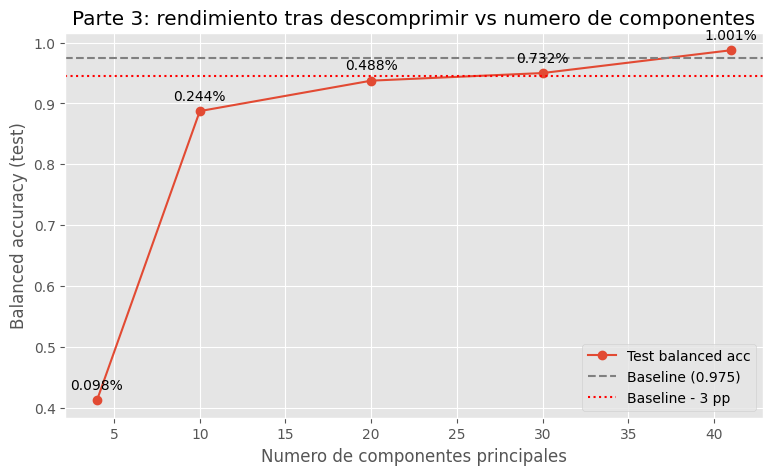

In [14]:
# 3. Visualizacion: balanced_accuracy en test frente al numero de componentes (y compresion)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(resultados_p3["n_componentes"], resultados_p3["test_balanced_acc"],
        marker="o", label="Test balanced acc")
ax.axhline(base_test, ls="--", color="gray", label=f"Baseline ({base_test:.3f})")
ax.axhline(base_test - 0.03, ls=":", color="red", label="Baseline - 3 pp")
for _, r in resultados_p3.iterrows():
    ax.annotate(f'{r["compresion_%"]}%',
                (r["n_componentes"], r["test_balanced_acc"]),
                textcoords="offset points", xytext=(0, 8), ha="center")
ax.set_xlabel("Numero de componentes principales")
ax.set_ylabel("Balanced accuracy (test)")
ax.set_title("Parte 3: rendimiento tras descomprimir vs numero de componentes")
ax.legend()
plt.show()

In [15]:
# 4. No podemos perder mas de 3 pp respecto al baseline -> cogemos la mayor compresion
#    (menos componentes) que cumpla esa condicion.
margen3 = 0.03
candidatos3 = resultados_p3[resultados_p3["dif_test_vs_base"] > -margen3]
elegido_p3 = int(candidatos3.sort_values("n_componentes").iloc[0]["n_componentes"])
print(f"Componentes elegidos (Parte 3): {elegido_p3}")
print(f"-> compresion {elegido_p3 / n_pixeles * 100:.2f}% con perdida < 3 pp en test")

Componentes elegidos (Parte 3): 30
-> compresion 0.73% con perdida < 3 pp en test


### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

**EXTRA 1:** scatter de las dos primeras componentes principales de la PCA elegida en la Parte 2, coloreando por clase. Como hay 40 clases, las repartimos en 4 graficos de 10 clases cada uno.

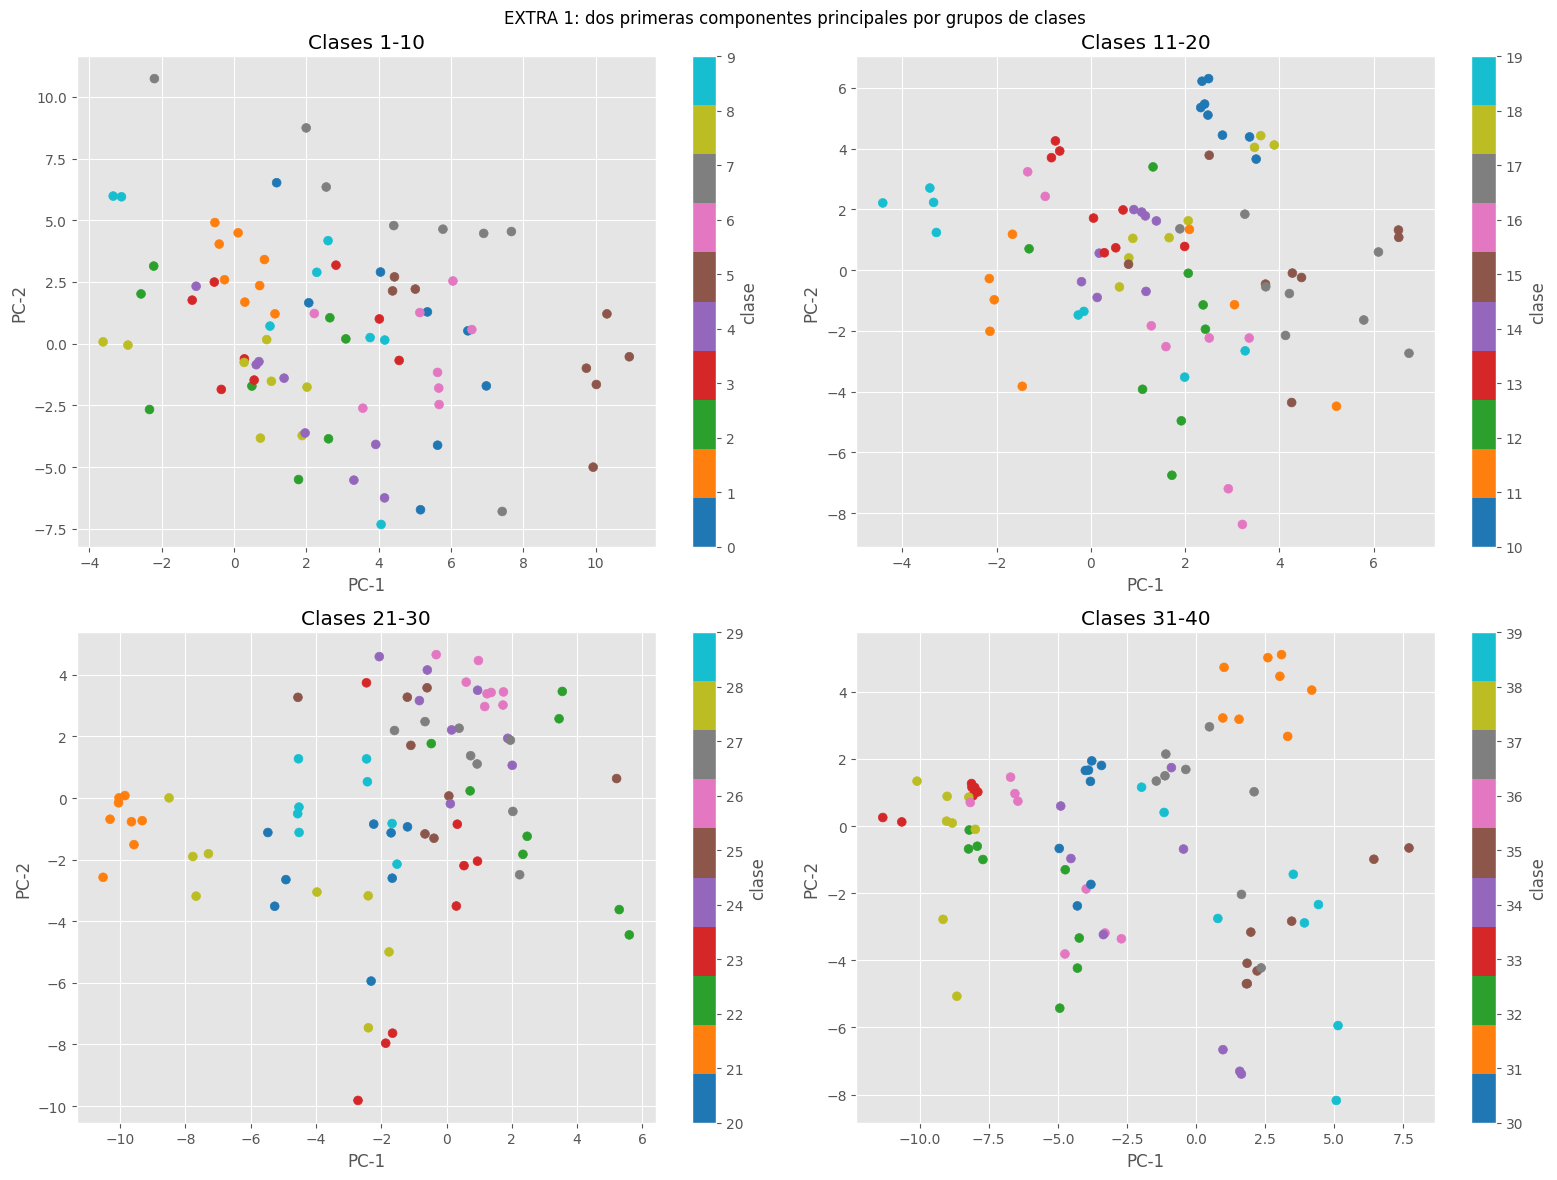

In [16]:
# Usamos la PCA elegida en la Parte 2 y la proyeccion del train.
pca_extra = PCA(n_components=elegido_p2).fit(X_train)
proj = pca_extra.transform(X_train)   # columnas 0 y 1 = PC1 y PC2

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, ax in enumerate(axes.ravel()):
    lo, hi = idx * 10, idx * 10 + 9            # ids 0-9, 10-19, 20-29, 30-39
    mask = (y_train >= lo) & (y_train <= hi)
    sc = ax.scatter(proj[mask, 0], proj[mask, 1],
                    c=y_train[mask], cmap="tab10", s=40)
    ax.set_title(f"Clases {lo + 1}-{hi + 1}")
    ax.set_xlabel("PC-1")
    ax.set_ylabel("PC-2")
    plt.colorbar(sc, ax=ax, label="clase")
plt.suptitle("EXTRA 1: dos primeras componentes principales por grupos de clases")
plt.tight_layout()
plt.show()

**EXTRA 2:** funcion para comparar una cara original con su version descomprimida (PCA + `inverse_transform`). La aplicamos a 5 caras para cada numero de componentes probado en la Parte 3, y anadimos los casos de 150 y 320 componentes para ver que con suficientes componentes las caras se reconstruyen con claridad (320 = maximo posible = reconstruccion perfecta).

In [17]:
# Funcion (adaptada de la practica de KMeans) para comparar original vs descomprimida.
def comparar_caras(X_orig, pca_modelo, indices, titulo=""):
    """Muestra, para los indices dados, la cara original (fila de arriba) y la
    cara descomprimida con el PCA dado (fila de abajo). Imagenes de 64x64."""
    X_unzip = pca_modelo.inverse_transform(pca_modelo.transform(X_orig))
    n = len(indices)
    fig, axes = plt.subplots(2, n, figsize=(2.2 * n, 5))
    for j, i in enumerate(indices):
        for row, datos, nombre in [(0, X_orig, "Original"),
                                   (1, X_unzip, "Descomprimida")]:
            ax = axes[row, j]
            ax.imshow(datos[i].reshape(64, 64), cmap="gray")
            ax.set_xticks([]); ax.set_yticks([])
            if j == 0:
                ax.set_ylabel(nombre)
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()

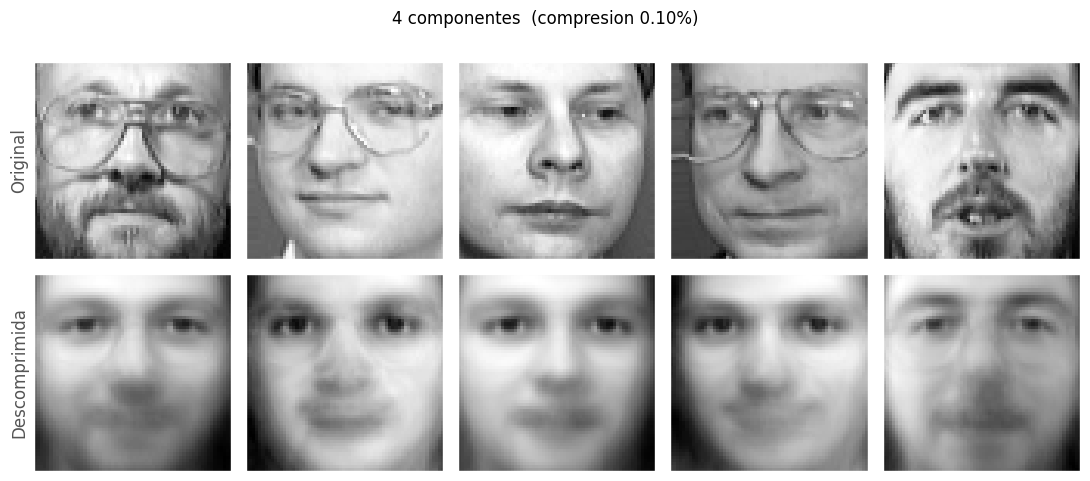

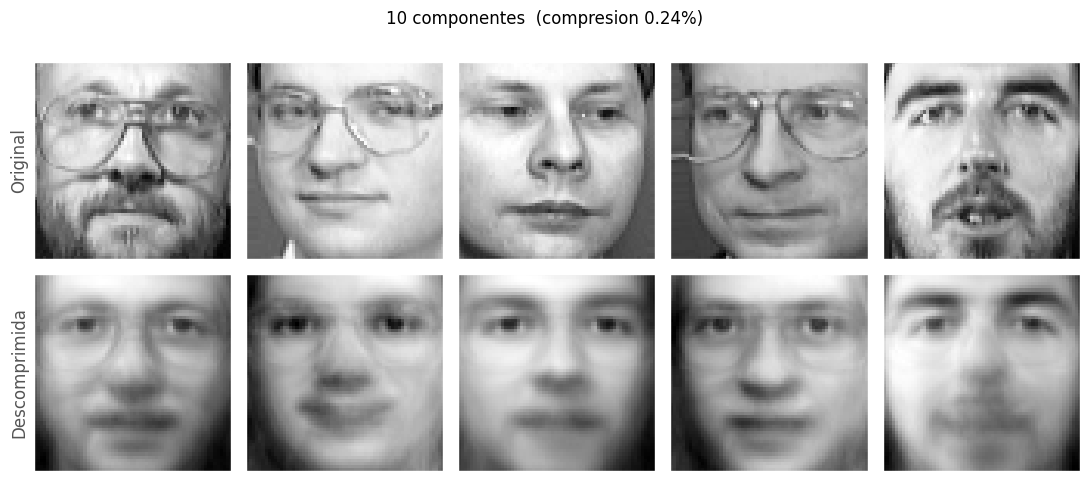

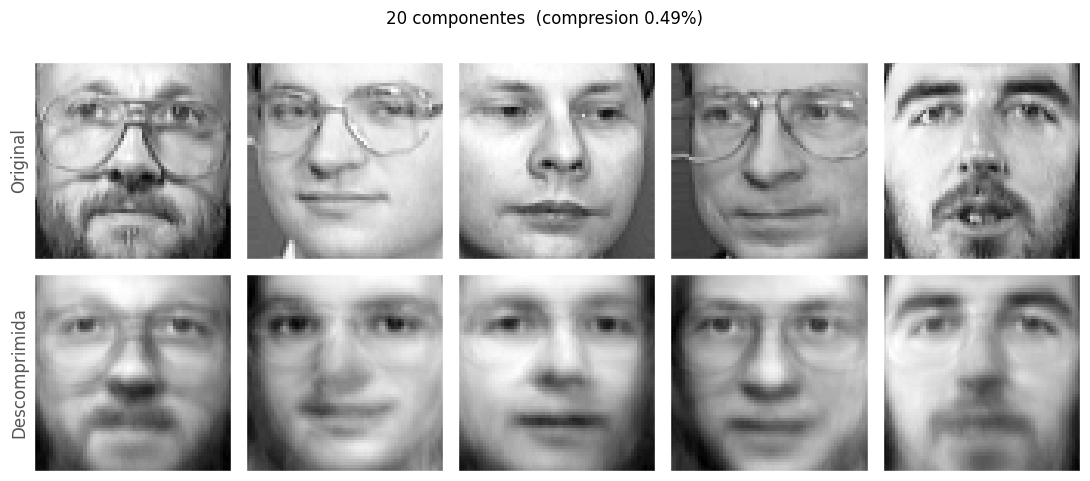

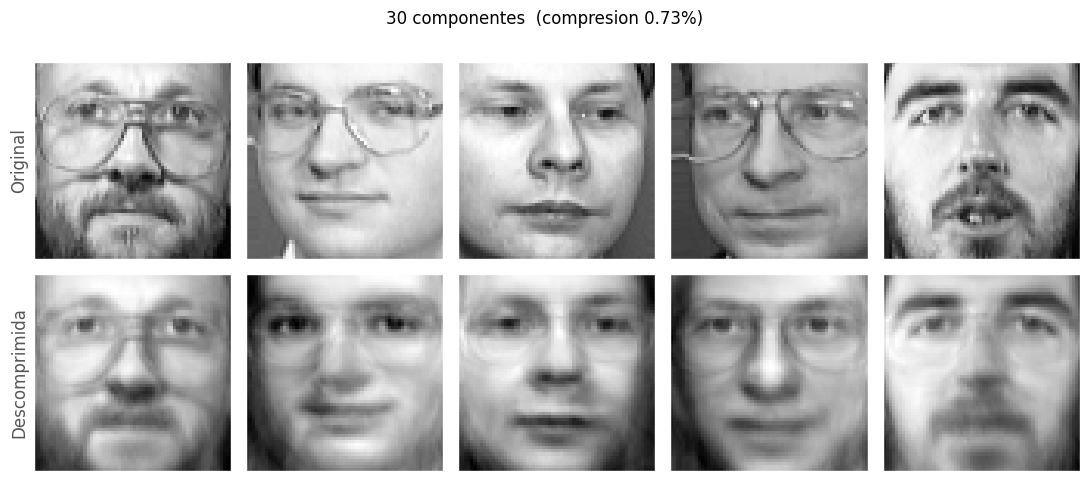

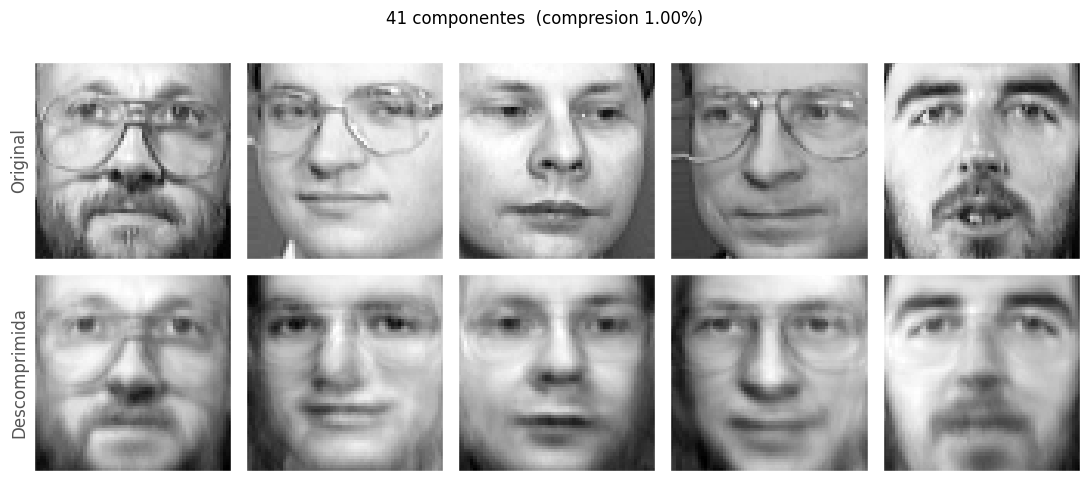

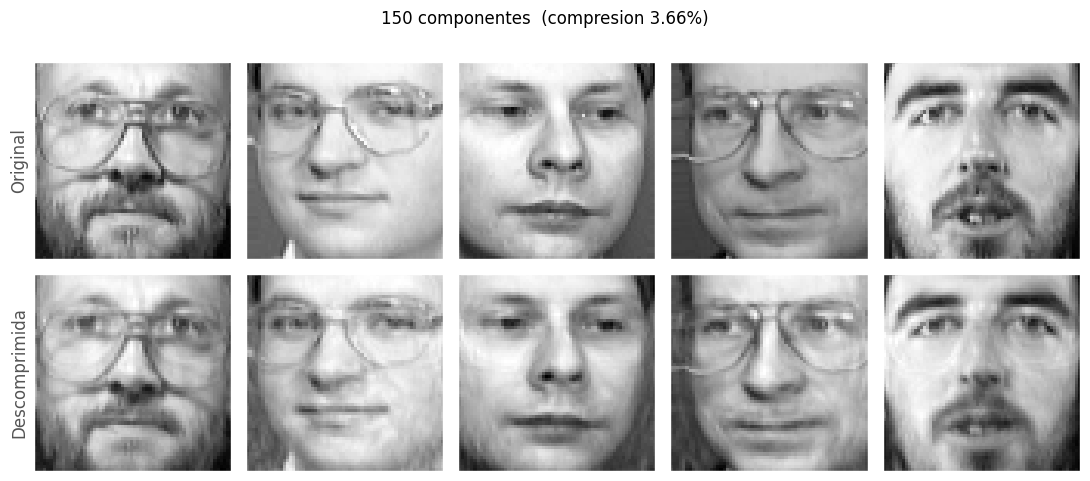

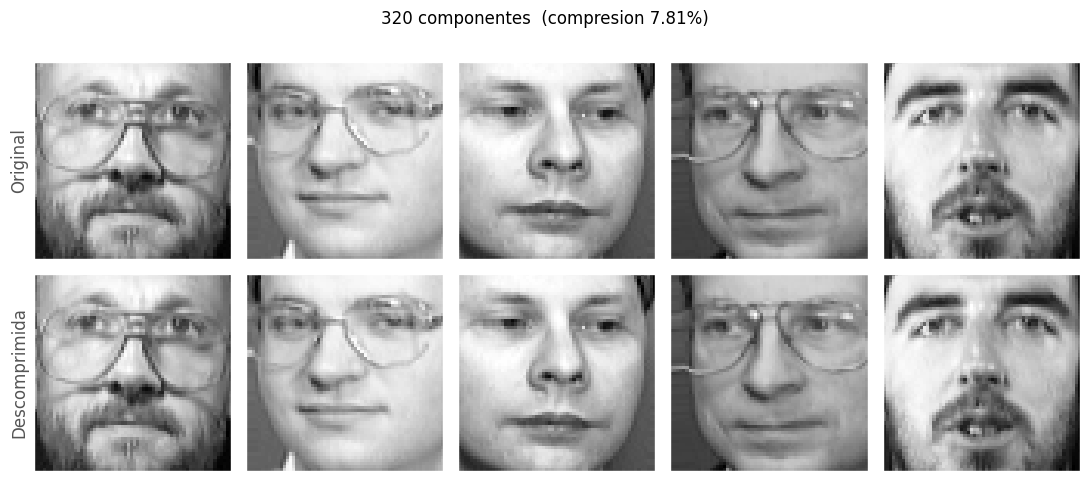

In [18]:
# 5 caras de ejemplo, para cada k de la Parte 3 mas los casos 150 y 320.
indices_muestra = [0, 1, 2, 3, 4]
for k in componentes_p3 + [150, 320]:
    pca_k = PCA(n_components=k).fit(X_train)
    comparar_caras(X_train, pca_k, indices_muestra,
                   titulo=f"{k} componentes  (compresion {k / n_pixeles * 100:.2f}%)")

## Conclusiones para el negocio

Recordando las dos opciones del Caesar Palace:

- **Opcion A - procesar en la microcamara con datos comprimidos (Parte 2):** el modelo clasifica directamente sobre las componentes PCA. Con **~50 componentes (compresion ~1.2%)** mantenemos el rendimiento dentro de los 3 puntos del baseline tanto en CV como en test.

- **Opcion B - enviar comprimido y clasificar en el servidor tras descomprimir (Parte 3):** aqui solo se transmiten las componentes (minimo ancho de banda) y el servidor descomprime antes de clasificar. Con **~30 componentes (compresion ~0.7%)** el modelo del servidor pierde menos de 3 puntos respecto al baseline.

**Recomendacion:** si el cuello de botella es el ancho de banda de las microcamaras, la **Opcion B** consigue una compresion mayor (menos datos por la red) manteniendo la precision, por lo que es la mas interesante para enviar al repositorio central. La Opcion A sigue siendo una alternativa valida si en algun momento se quisiera clasificar en la propia camara sin descomprimir, a costa de transmitir/almacenar algo mas. Los numeros exactos elegidos quedan en `elegido_p2` y `elegido_p3`.